In [ ]:
!pip install category_encoders


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: C:\Users\dangt\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
import category_encoders as ce

warnings.filterwarnings('ignore')
%matplotlib inline

In [4]:

df_1 = pd.read_csv(r"https://media.githubusercontent.com/media/pentakll4002/IS403_Q13/refs/heads/main/data/Fraudulent_E-Commerce_Transaction_Data.csv")
df_2 = pd.read_csv(r"https://raw.githubusercontent.com/pentakll4002/IS403_Q13/refs/heads/main/data/Fraudulent_E-Commerce_Transaction_Data_2.csv")

In [5]:
df = pd.concat([df_1, df_2], ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1496586 entries, 0 to 1496585
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1496586 non-null  object 
 1   Customer ID         1496586 non-null  object 
 2   Transaction Amount  1496586 non-null  float64
 3   Transaction Date    1496586 non-null  object 
 4   Payment Method      1496586 non-null  object 
 5   Product Category    1496586 non-null  object 
 6   Quantity            1496586 non-null  int64  
 7   Customer Age        1496586 non-null  int64  
 8   Customer Location   1496586 non-null  object 
 9   Device Used         1496586 non-null  object 
 10  IP Address          1496586 non-null  object 
 11  Shipping Address    1496586 non-null  object 
 12  Billing Address     1496586 non-null  object 
 13  Is Fraudulent       1496586 non-null  int64  
 14  Account Age Days    1496586 non-null  int64  
 15  Transaction Hou

In [6]:
df.head(5)

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [7]:
df.count

<bound method DataFrame.count of                                Transaction ID  \
0        15d2e414-8735-46fc-9e02-80b472b2580f   
1        0bfee1a0-6d5e-40da-a446-d04e73b1b177   
2        e588eef4-b754-468e-9d90-d0e0abfc1af0   
3        4de46e52-60c3-49d9-be39-636681009789   
4        074a76de-fe2d-443e-a00c-f044cdb68e21   
...                                       ...   
1496581  d8b7171f-bdd9-479c-b98b-396c621aebfe   
1496582  0fd12cf3-c641-4499-8de1-15dc4555cb0c   
1496583  649680d3-a684-44cb-95bf-9b454c3aa86d   
1496584  c10dbb08-28fc-4ec1-9850-d4e98d2b9640   
1496585  23e3c107-f2fc-48c2-abbc-7b809bf6f102   

                                  Customer ID  Transaction Amount  \
0        d1b87f62-51b2-493b-ad6a-77e0fe13e785               58.09   
1        37de64d5-e901-4a56-9ea0-af0c24c069cf              389.96   
2        1bac88d6-4b22-409a-a06b-425119c57225              134.19   
3        2357c76e-9253-4ceb-b44e-ef4b71cb7d4d              226.17   
4        45071bc5-9588-43ea-8093-

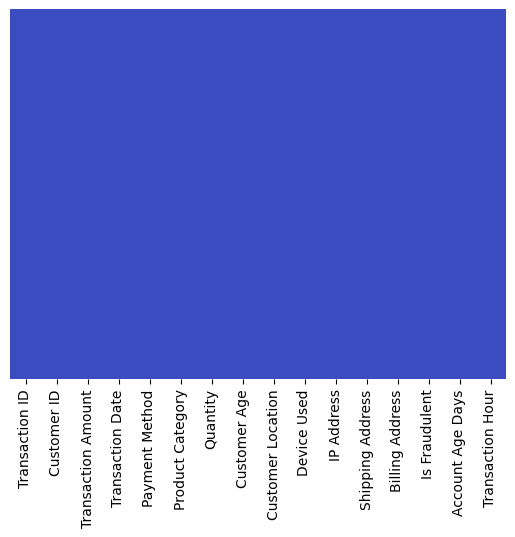

In [8]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap="coolwarm")
plt.show()

In [9]:
df.describe()

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour
count,1.496586e+06,1.496586e+06,1.496586e+06,1.496586e+06,1.496586e+06,1.496586e+06
mean,2.268093e+02,3.000235e+00,3.451284e+01,5.015415e-02,1.796308e+02,1.128663e+01
std,2.705831e+02,1.414814e+00,1.000323e+01,2.182630e-01,1.068726e+02,6.976067e+00
min,1.000000e+01,1.000000e+00,-1.600000e+01,0.000000e+00,1.000000e+00,0.000000e+00
25%,6.862000e+01,2.000000e+00,2.800000e+01,0.000000e+00,8.600000e+01,5.000000e+00
50%,1.517600e+02,3.000000e+00,3.500000e+01,0.000000e+00,1.790000e+02,1.100000e+01
75%,2.960500e+02,4.000000e+00,4.100000e+01,0.000000e+00,2.720000e+02,1.700000e+01
max,1.270175e+04,5.000000e+00,8.600000e+01,1.000000e+00,3.650000e+02,2.300000e+01


In [10]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Transaction Amount',
       'Transaction Date', 'Payment Method', 'Product Category', 'Quantity',
       'Customer Age', 'Customer Location', 'Device Used', 'IP Address',
       'Shipping Address', 'Billing Address', 'Is Fraudulent',
       'Account Age Days', 'Transaction Hour'],
      dtype='object')

In [11]:
print(len(df.columns))

16


In [12]:
# plt.figure(figsize=(10, 50))

# for i in range(len(df.columns)):
#     plt.subplot(17, 1, i + 1)
#     sns.histplot(df[df.columns[i]], kde=True, color="g")
#     plt.title(df.columns[i])

# plt.tight_layout()
# plt.show()

In [13]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

df['Transaction_Year'] = df['Transaction Date'].dt.year
df['Transaction_Month'] = df['Transaction Date'].dt.month
df['Transaction_Day'] = df['Transaction Date'].dt.day
df['Transaction_Hour'] = df['Transaction Date'].dt.hour
df['Transaction_Minute'] = df['Transaction Date'].dt.minute
df['Transaction_Second'] = df['Transaction Date'].dt.second
df['Transaction_DayOfWeek'] = df['Transaction Date'].dt.dayofweek
df['Is_Weekend'] = df['Transaction_DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

df[['Transaction Date', 'Transaction_Year', 'Transaction_Month', 'Transaction_Day',
    'Transaction_Hour', 'Transaction_DayOfWeek', 'Is_Weekend']].head()


,Transaction Date,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_Hour,Transaction_DayOfWeek,Is_Weekend
0,2024-02-20 05:58:41,2024,2,20,5,1,0
1,2024-02-25 08:09:45,2024,2,25,8,6,1
2,2024-03-18 03:42:55,2024,3,18,3,0,0
3,2024-03-16 20:41:31,2024,3,16,20,5,1
4,2024-01-15 05:08:17,2024,1,15,5,0,0


In [14]:
df.drop(columns=["Transaction Date"], inplace=True)

In [15]:
df.head(5)

,Transaction ID,Customer ID,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,...,Account Age Days,Transaction Hour,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_Hour,Transaction_Minute,Transaction_Second,Transaction_DayOfWeek,Is_Weekend
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,...,30,5,2024,2,20,5,58,41,1,0
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,...,72,8,2024,2,25,8,9,45,6,1
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,...,63,3,2024,3,18,3,42,55,0,0
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,...,124,20,2024,3,16,20,41,31,5,1
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,...,158,5,2024,1,15,5,8,17,0,0


In [ ]:
cols_to_drop = [
    "Transaction ID",
    "Customer ID",
    "Shipping Address",
    "Billing Address"
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [17]:
df.head()

,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Is Fraudulent,Account Age Days,Transaction Hour,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_Hour,Transaction_Minute,Transaction_Second,Transaction_DayOfWeek,Is_Weekend
0,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,0,30,5,2024,2,20,5,58,41,1,0
1,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,0,72,8,2024,2,25,8,9,45,6,1
2,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,0,63,3,2024,3,18,3,42,55,0,0
3,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,0,124,20,2024,3,16,20,41,31,5,1
4,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,0,158,5,2024,1,15,5,8,17,0,0


In [18]:
import ipaddress

def ip_to_int(ip):
    try:
        return int(ipaddress.ip_address(ip))
    except:
        return None

df['IP_Int'] = df['IP Address'].apply(ip_to_int)
df.drop(columns=["IP Address"], inplace=True)

In [19]:
df.head()

,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,Is Fraudulent,Account Age Days,Transaction Hour,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_Hour,Transaction_Minute,Transaction_Second,Transaction_DayOfWeek,Is_Weekend,IP_Int
0,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,0,30,5,2024,2,20,5,58,41,1,0,3569562054
1,389.96,debit card,electronics,2,40,East Timothy,desktop,0,72,8,2024,2,25,8,9,45,6,1,3496671609
2,134.19,PayPal,home & garden,2,22,Davismouth,tablet,0,63,3,2024,3,18,3,42,55,0,0,1279219924
3,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,0,124,20,2024,3,16,20,41,31,5,1,3486559049
4,121.53,bank transfer,clothing,2,51,South Nicole,tablet,0,158,5,2024,1,15,5,8,17,0,0,3198946985


In [20]:
categorical_features = ["Payment Method", "Product Category", "Customer Location", "Device Used"]
target = "Is Fraudulent"


In [22]:
# X_sample = sample.drop(columns=[target])
# y_sample = sample[target]
X_sample = df.drop(columns=[target])
y_sample = df[target]


In [23]:
import umap.umap_ as umap

In [24]:
pipeline = Pipeline(steps=[
    ('encoder', ce.TargetEncoder(cols=categorical_features, smoothing=0.2)),
    ('scaler', StandardScaler(with_mean=False)), # (nên bật with_mean=False để tránh lỗi khi dữ liệu sparse)
    ('pca', PCA(n_components=0.95, svd_solver='full', random_state=42)), # PCA giảm chiều để giảm tính toán trước
    ('umap', umap.UMAP( # UMAP giảm tiếp xuống 2 chiều để trực quan hóa
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        random_state=42,
        low_memory=True,   # Giảm RAM
        n_jobs=-1,          # Dùng đa lõi
        metric='cosine',
        transform_seed=42,
        init='random'
    ))
])

In [25]:
X_reduced = pipeline.fit_transform(X_sample, y_sample)

Optimal number of clusters (Elbow): 5


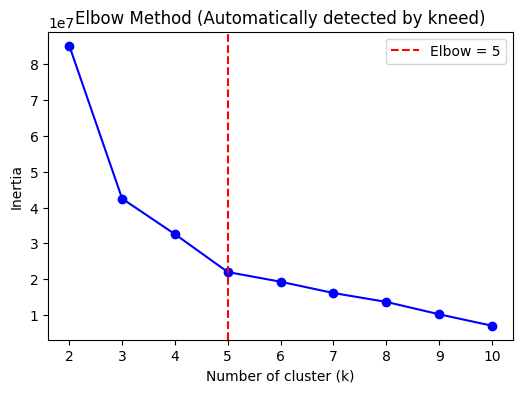

In [36]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt

inertias = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_reduced)
    inertias.append(kmeans.inertia_)

kl = KneeLocator(K, inertias, curve="convex", direction="decreasing")
optimal_k = kl.elbow

print(f"Optimal number of clusters (Elbow): {optimal_k}")

plt.figure(figsize=(6,4))
plt.plot(K, inertias, 'bo-')
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Elbow = {optimal_k}')
plt.xlabel('Number of cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (Automatically detected by kneed)')
plt.legend()
plt.show()

In [37]:
kmeans_final = KMeans(n_clusters=5, random_state=42)
kmeans_final.fit(X_reduced)
labels = kmeans_final.labels_

In [38]:
data_clt = kmeans_final.cluster_centers_.shape
print(f"Shape of cluster centers: {data_clt}")

Shape of cluster centers: (5, 2)


In [39]:
cluster_centers = pd.DataFrame(
    data = kmeans_final.cluster_centers_,
    columns = [f"PCA_{i+1}" for i in range(X_reduced.shape[1])]
)

print("\nCluster Centers:")
cluster_centers


Cluster Centers:


,PCA_1,PCA_2
0,1.140089,11.528282
1,11.979255,8.212530
2,8.966768,-4.722128
3,-7.769654,9.630920
4,-1.799222,-0.071704


In [40]:
labels.shape

(1496586,)

In [41]:
print(labels.max())
print(labels.min())

4
0


In [42]:
y_kmeans = kmeans.fit_predict(X_reduced)
y_kmeans

array([5, 2, 1, ..., 1, 3, 2], shape=(1496586,), dtype=int32)

In [43]:
df_cluster = pd.DataFrame(
    X_reduced,
    columns=[f"PCA_{i+1}" for i in range(X_reduced.shape[1])]
)
df_cluster['cluster'] = labels

print("DataFrame with cluster labels:")
df_cluster.head()

DataFrame with cluster labels:


,PCA_1,PCA_2,cluster
0,-6.420487,0.858062,4
1,7.335747,-0.596180,2
2,12.124798,9.598569,1
3,-8.615993,8.705572,3
4,11.425132,5.258360,1


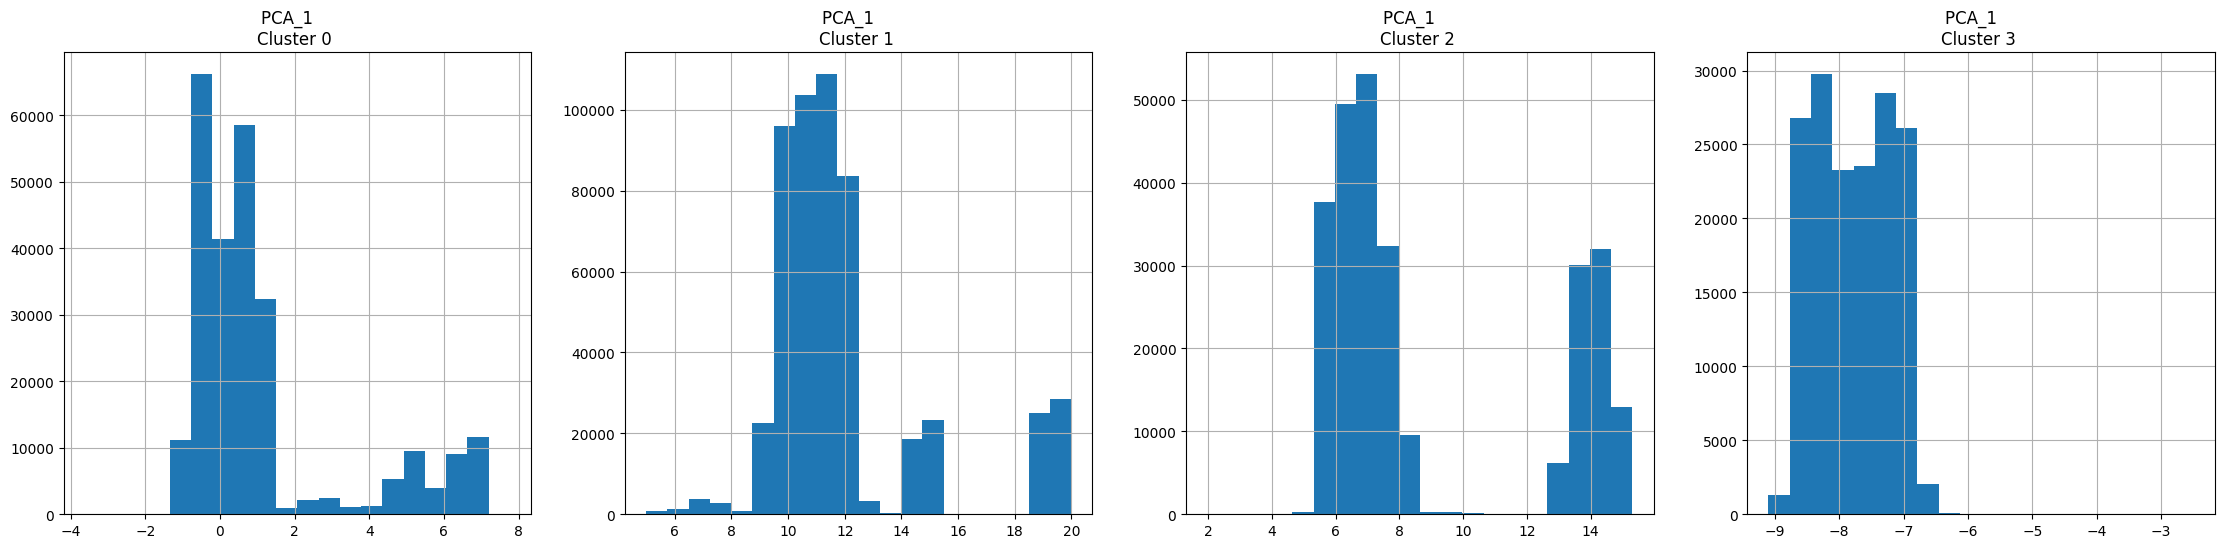

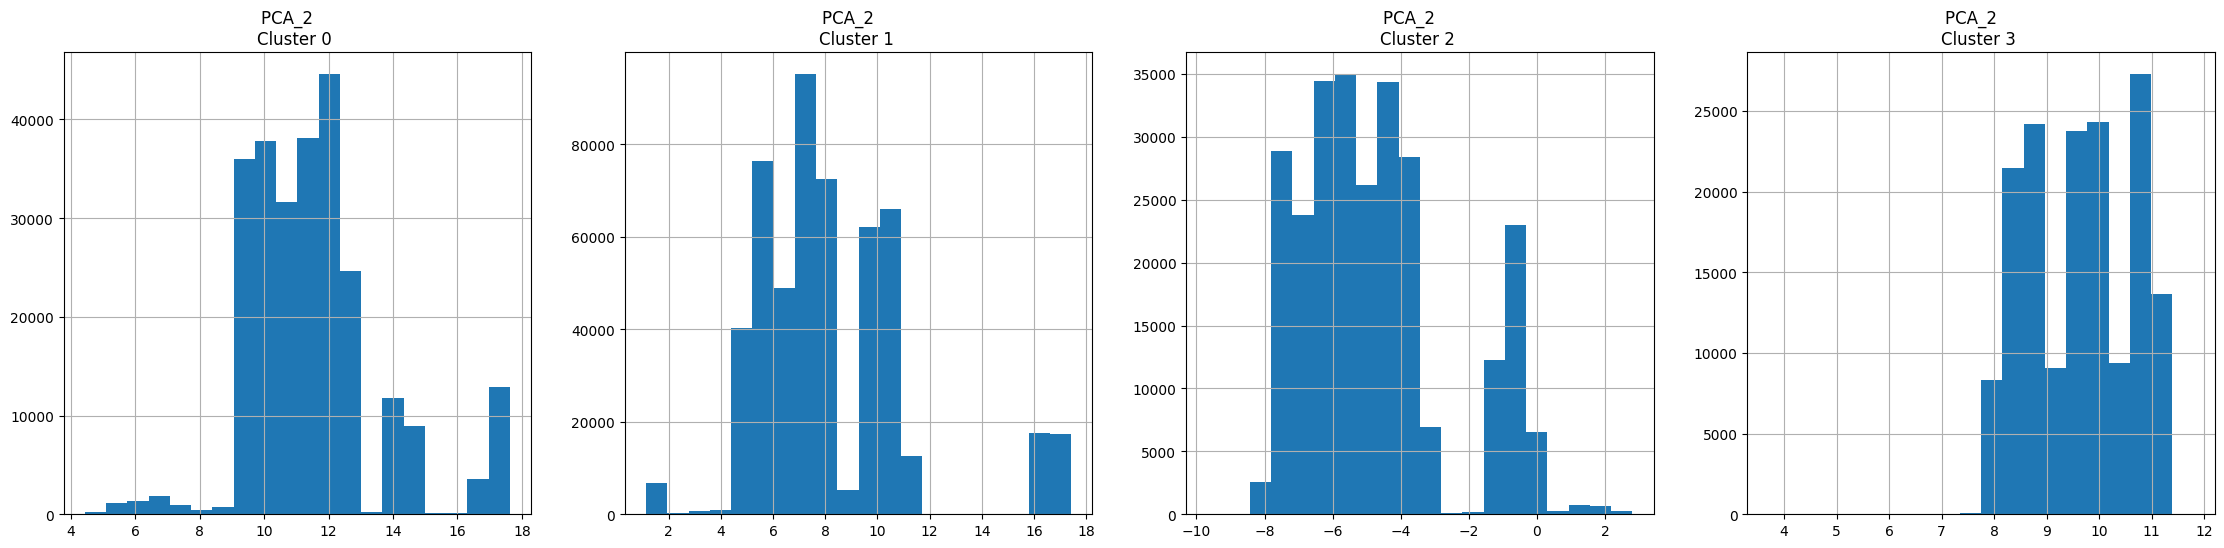

In [47]:
# Plot the histogram of various clusters
for i in df_cluster.columns[:-1]:
    plt.figure(figsize = (35, 6))
    for j in range(4):
        plt.subplot(1,5,j+1)
        cluster = df_cluster[df_cluster['cluster'] == j]
        cluster[i].hist(bins = 20)
        plt.title('{}    \nCluster {} '.format(i,j))

    plt.show()


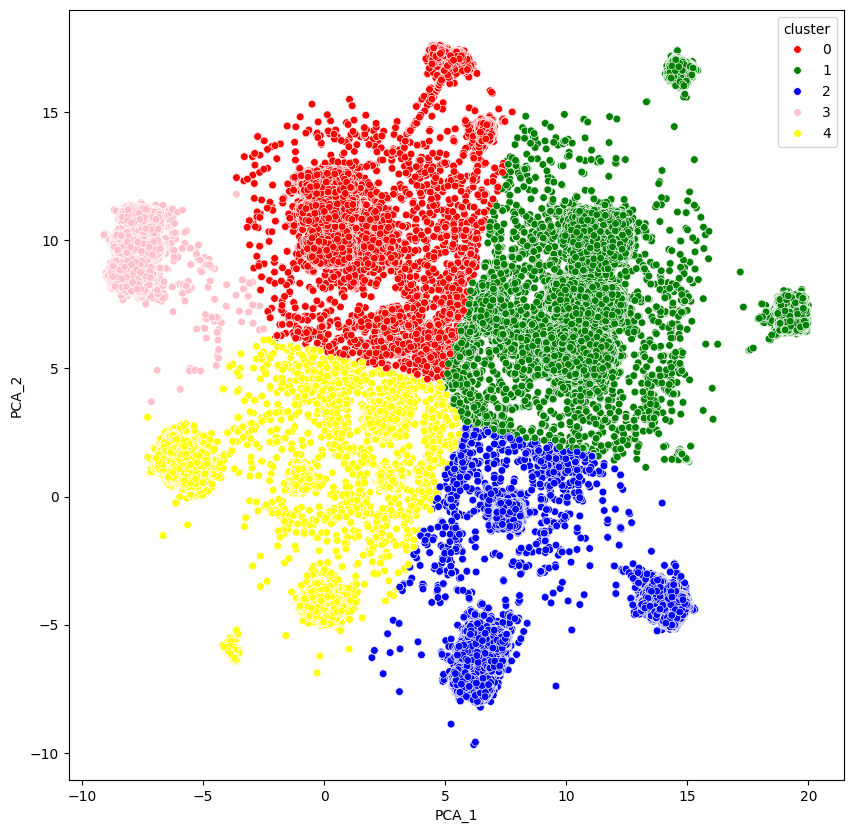

In [ ]:
plt.figure(figsize=(10,10))
sns.scatterplot(
    x="PCA_1", y="PCA_2",
    hue="cluster",
    data=df_cluster,
    palette=['red','green','blue','pink','yellow','orange'],
    s=30
)
plt.show()
